# Практика: Снижение размерности — PCA, t-SNE и UMAP

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и исследуете датасет `digits` (рукописные цифры);
2. примените **PCA** как препроцессинг: выберете число компонент по cumulative EVR;
3. проинтерпретируете главные компоненты через **loadings**;
4. обучите классификатор на PCA-признаках и сравните с обучением на исходных признаках;
5. визуализируете структуру данных через **t-SNE** и **UMAP**;
6. сравните 2D-проекции PCA, t-SNE и UMAP: насколько хорошо разделяются классы?

## Датасет
Мы используем `digits` из `sklearn.datasets`:
- 1797 изображений рукописных цифр 0–9;
- каждое изображение — 8×8 пикселей = **64 признака** (интенсивность пикселей);
- задача: 10-классовая классификация.

## Что сдавать
1. Заполненный ноутбук со всем кодом.
2. Краткие выводы в конце:
   - сколько компонент PCA достаточно для сохранения 95% дисперсии?
   - как влияет PCA-препроцессинг на качество классификатора?
   - какой метод визуализации (PCA, t-SNE, UMAP) лучше разделяет классы?

---
## Шаг 1. Загрузка и первичный анализ данных

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

digits = load_digits()
X = digits.data
y = digits.target

print(f"Форма X: {X.shape}")
print(f"Классы: {np.unique(y)}")
print(f"Признаки: {X.shape[1]} (8x8 пикселей)")

Форма X: (1797, 64)
Классы: [0 1 2 3 4 5 6 7 8 9]
Признаки: 64 (8x8 пикселей)


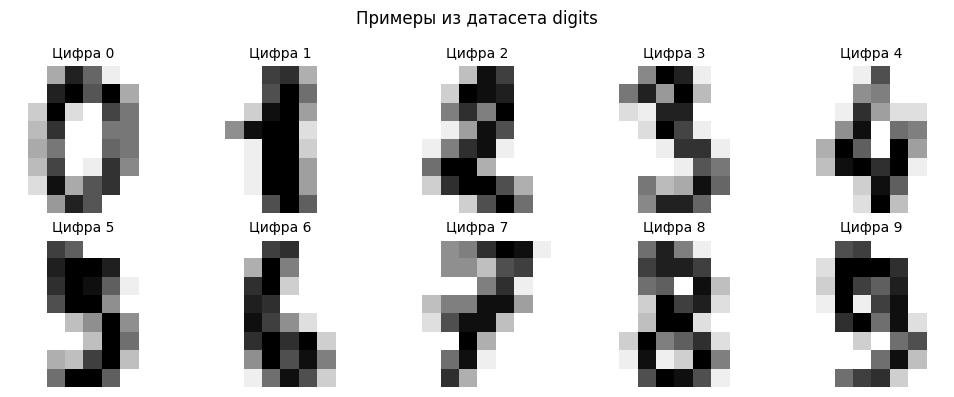

In [5]:
# Визуализируем примеры из каждого класса
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    sample_idx = np.where(y == idx)[0][0]
    ax.imshow(X[sample_idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Цифра {idx}', fontsize=10)
    ax.axis('off')
plt.suptitle('Примеры из датасета digits', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
# Стандартизация — обязательный шаг перед PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Среднее до: {X.mean():.2f}, после: {X_scaled.mean():.4f}")
print(f"Std до: {X.std():.2f}, после: {X_scaled.std():.4f}")

Среднее до: 4.88, после: 0.0000
Std до: 6.02, после: 0.9763


---
## Шаг 2. PCA: explained variance и выбор числа компонент

Обучите PCA на всех 64 компонентах. Постройте график накопленной объясняемой дисперсии.
Определите, сколько компонент нужно для сохранения 80%, 95% и 99% дисперсии.

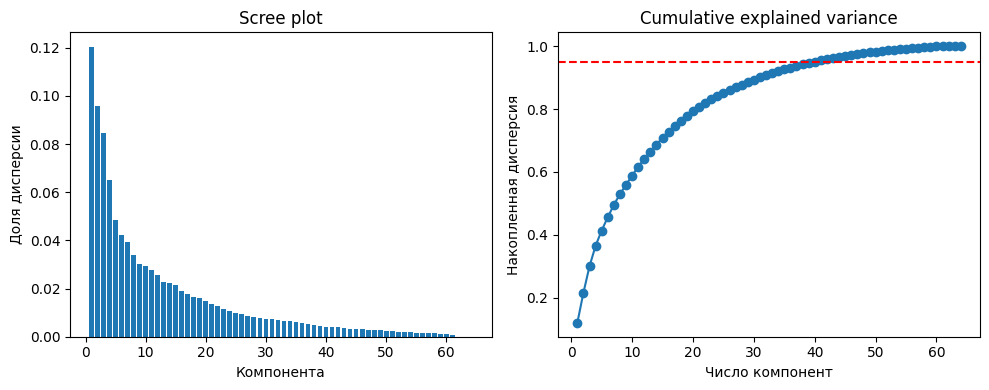

80% дисперсии -> 21 компонент
95% дисперсии -> 40 компонент
99% дисперсии -> 54 компонент


In [7]:
# Обучите PCA на всех компонентах
pca_full = PCA(n_components=64, random_state=42)
X_pca = pca_full.fit_transform(X_scaled)

evr = pca_full.explained_variance_ratio_
# Вычислите накопленную объясняемую дисперсию
cumvar = evr.cumsum()

# Постройте график: по оси X — число компонент, по оси Y — cumvar
# Добавьте горизонтальные линии для 80%, 95%, 99%
fig,axes = plt.subplots(1,2,figsize=(10,4))
axes[0].bar(range(1, len(evr)+1),evr)
axes[0].set_xlabel('Компонента')
axes[0].set_ylabel('Доля дисперсии')
axes[0].set_title('Scree plot')

axes[1].plot(range(1, len(cumvar)+1),cumvar,marker='o')
axes[1].axhline(0.95, color='red', linestyle='--',label='95%')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Накопленная дисперсия')
axes[1].set_title('Cumulative explained variance')

plt.tight_layout()
plt.show()

# Найдите минимальное k для каждого порога
for threshold in [0.80, 0.95, 0.99]:
    k = np.argmax(cumvar >= threshold) + 1
    print(f"{int(threshold*100)}% дисперсии -> {k} компонент")

По графикам видно, что 40 компонент довольно хорошо описывают 95% процентов дисперсии, что является стандартом дефакто, остальные 5% можно выкинуть, тк они в среднем несут шум, и в дальнейшем только ухудшают обучение

---
## Шаг 3. PCA для визуализации (2 компоненты)

Спроецируйте данные на 2 главных компоненты. Визуализируйте scatter plot с раскраской по классу.
Укажите долю объяснённой дисперсии на осях.

PC1: 12.0%
PC2: 9.6%
Итого: 21.6%


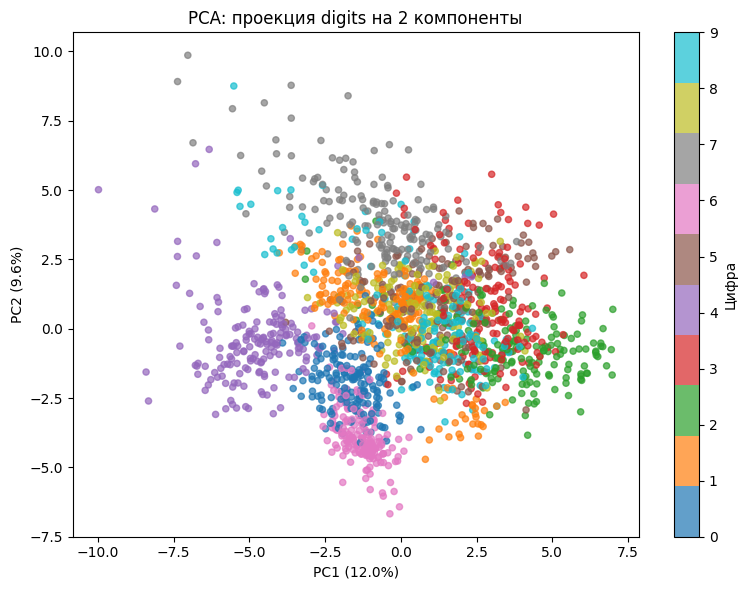

In [8]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

print(f"PC1: {pca2.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca2.explained_variance_ratio_[1]*100:.1f}%")
print(f"Итого: {pca2.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca2[:, 0],
    X_pca2[:, 1],
    c=y,
    cmap='tab10',
    s=20,
    alpha=0.7
)
plt.colorbar(scatter,label='Цифра')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: проекция digits на 2 компоненты')
plt.tight_layout()
plt.show()

По графику видно, что PCA довольно плохо справился с визуализацией юзая первые 2 компоненты (использовалось 21% дисперсии от исходной :/ ), хотя можно выделить группы точек как четверки, шестерки и двойки, но для модели две компоненты это довольно мало (она просто сойдет с ума), а для визуализации желательно использовать t-SNE и UMAP

---
## Шаг 4. Интерпретация: loadings (нагрузки)

Визуализируйте нагрузки PC1 и PC2 как 8×8 изображения.
Яркие пиксели = сильное влияние на данную компоненту.
Используйте diverging colormap `'RdBu_r'`.

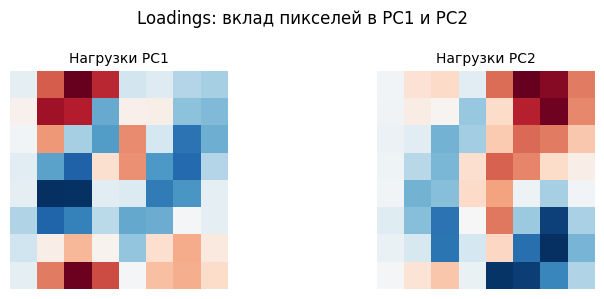

In [9]:
# pca2.components_ имеет форму (2, 64)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, ax in enumerate(axes):
    loading = pca2.components_[i].reshape(8,8)
    im = ax.imshow(loading, cmap='RdBu_r')
    ax.set_title(f'Нагрузки PC{i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle('Loadings: вклад пикселей в PC1 и PC2', fontsize=12)
plt.tight_layout()
plt.show()

# Вопрос: какие области изображения наиболее важны для PC1 и PC2?

1) для PC1 наиболее важным признаком является левая вертикальная зона(положительный вес) и центрально-правая дуга(отрицательный вес).Компонента фактически разделяет цифры по горизонтальному распределению веса пикселей

2) для PC2 наиболее важным признаком является верхний правый сектор(положительный вес) и нижний сектор(отрицательный вес), что позволяет разделять цифры по вертикальным геометрическим признакам

---
## Шаг 5. PCA как препроцессинг для классификатора

Сравните качество LogisticRegression:
1. На исходных 64 признаках
2. На PCA 95% дисперсии
3. На PCA 80% дисперсии

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

results = {}

# --- Вариант 1: без PCA ---
clf_base = LogisticRegression(max_iter=1000, random_state=42)
clf_base.fit(X_train, y_train)
y_pred_base = clf_base.predict(X_test)
results['Без PCA (64 признака)'] = accuracy_score(y_test,y_pred_base)

# --- Вариант 2: PCA с 95% дисперсии ---
# Подсказка: PCA(n_components=0.95) автоматически выбирает k
pca_95 = PCA(n_components=0.95, random_state=42)
X_train_95 = pca_95.fit_transform(X_train)
X_test_95  = pca_95.transform(X_test)
clf_95 = LogisticRegression(max_iter=1000, random_state=42)
clf_95.fit(X_train_95, y_train)
y_pred_95 = clf_95.predict(X_test_95)
results[f'PCA 95% ({pca_95.n_components_} компонент)'] = accuracy_score(y_test, y_pred_95)

# --- Вариант 3: PCA с 80% дисперсии ---
pca_80 = PCA(n_components=0.80, random_state=42)
X_train_80 = pca_80.fit_transform(X_train)
X_test_80 = pca_80.transform(X_test)
clf_80 = LogisticRegression(max_iter=1000, random_state=42)
clf_80.fit(X_train_80,y_train)
y_pred_80 = clf_80.predict(X_test_80)
results[f'PCA 80% ({pca_80.n_components_} компонент)'] = accuracy_score(y_test,y_pred_80)

print("Сравнение accuracy:")
print("-" * 45)
for name, acc in results.items():
    print(f"{name:35s}: {acc:.4f}")

Сравнение accuracy:
---------------------------------------------
Без PCA (64 признака)              : 0.9722
PCA 95% (40 компонент)             : 0.9639
PCA 80% (21 компонент)             : 0.9472


PCA на 40 компонентах показал почти такой же результат как и без PCA, НО при этом мы викинули 38% шума и почти не потеряли в метрике качетсва :)

---
## Шаг 6. t-SNE: нелинейная визуализация

Рекомендуемый пайплайн: сначала PCA до 30 компонент, затем t-SNE. Это ускоряет работу и убирает шум.

После PCA(30): 89.3% дисперсии


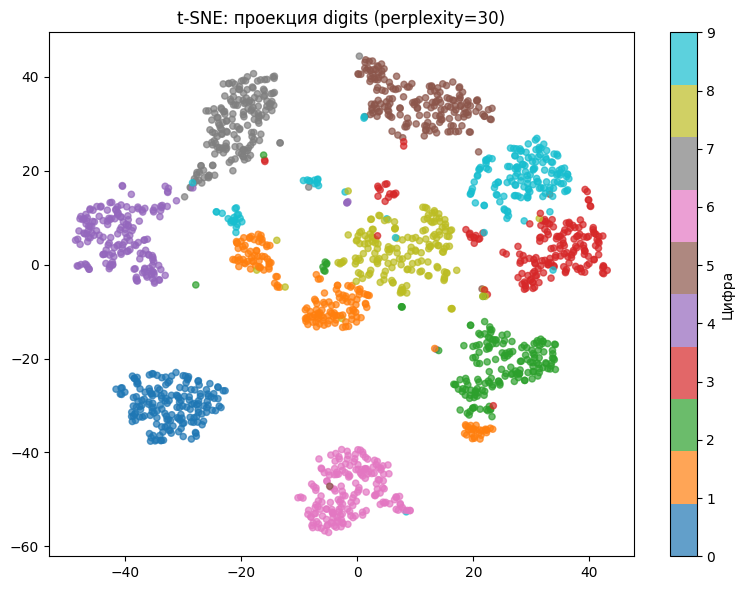

In [11]:
# PCA до 30 компонент (препроцессинг перед t-SNE)
pca_30 = PCA(n_components=30, random_state=42)
X_pca30 = pca_30.fit_transform(X_scaled)
print(f"После PCA(30): {pca_30.explained_variance_ratio_.sum()*100:.1f}% дисперсии")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca30)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='tab10',
    s=20,
    alpha=0.7
)
plt.colorbar(scatter, label='Цифра')
plt.title('t-SNE: проекция digits (perplexity=30)')
plt.tight_layout()
plt.show()

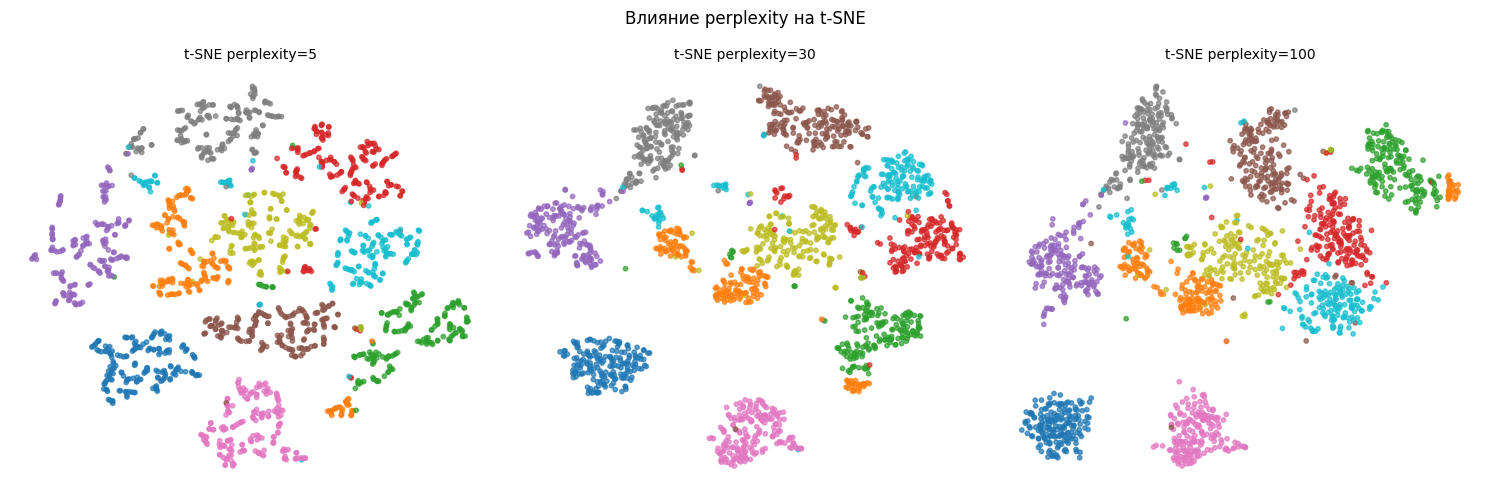

In [12]:
# Эксперимент с perplexity: 5, 30, 100
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, perp in zip(axes, [5, 30, 100]):
    tsne_p = TSNE(n_components=2, perplexity=perp, random_state=42)
    # YOUR CODE HERE: fit_transform и scatter
    X_tsne_p = tsne_p.fit_transform(X_pca30)

    ax.scatter(
        X_tsne_p[:,0],
        X_tsne_p[:,1],
        c=y,
        cmap='tab10',
        s=10,
        alpha=0.7
    )
    ax.set_title(f't-SNE perplexity={perp}', fontsize=10)
    ax.axis('off')

plt.suptitle('Влияние perplexity на t-SNE', fontsize=12)
plt.tight_layout()
plt.show()

---
## Шаг 7. UMAP

Если не установлен: `pip install umap-learn`

umap-learn доступен


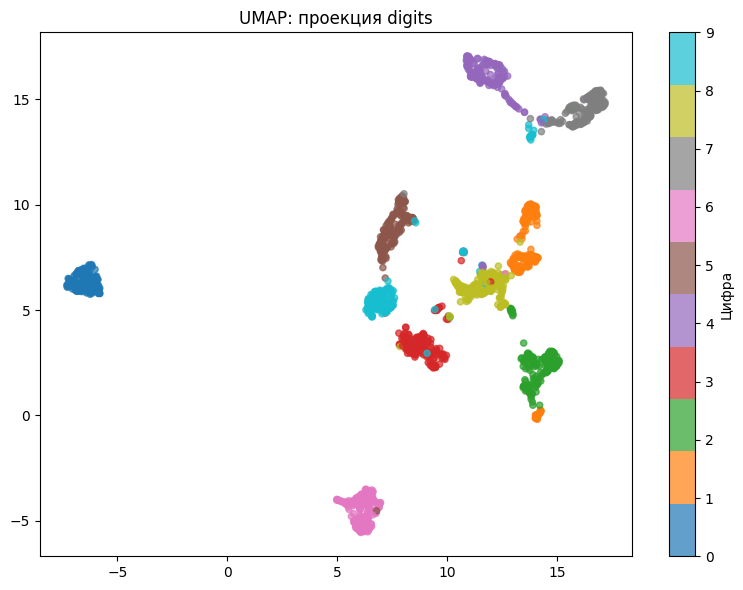

In [13]:
try:
    import umap
    UMAP_AVAILABLE = True
    print("umap-learn доступен")
except ImportError:
    print("Установите: pip install umap-learn")
    UMAP_AVAILABLE = False

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y,
    cmap='tab10',
    s=20,
    alpha=0.7
    )
    plt.colorbar(scatter,label='Цифра')
    plt.title('UMAP: проекция digits')
    plt.tight_layout()
    plt.show()

---
## Шаг 8. Сравнение проекций: PCA vs t-SNE vs UMAP

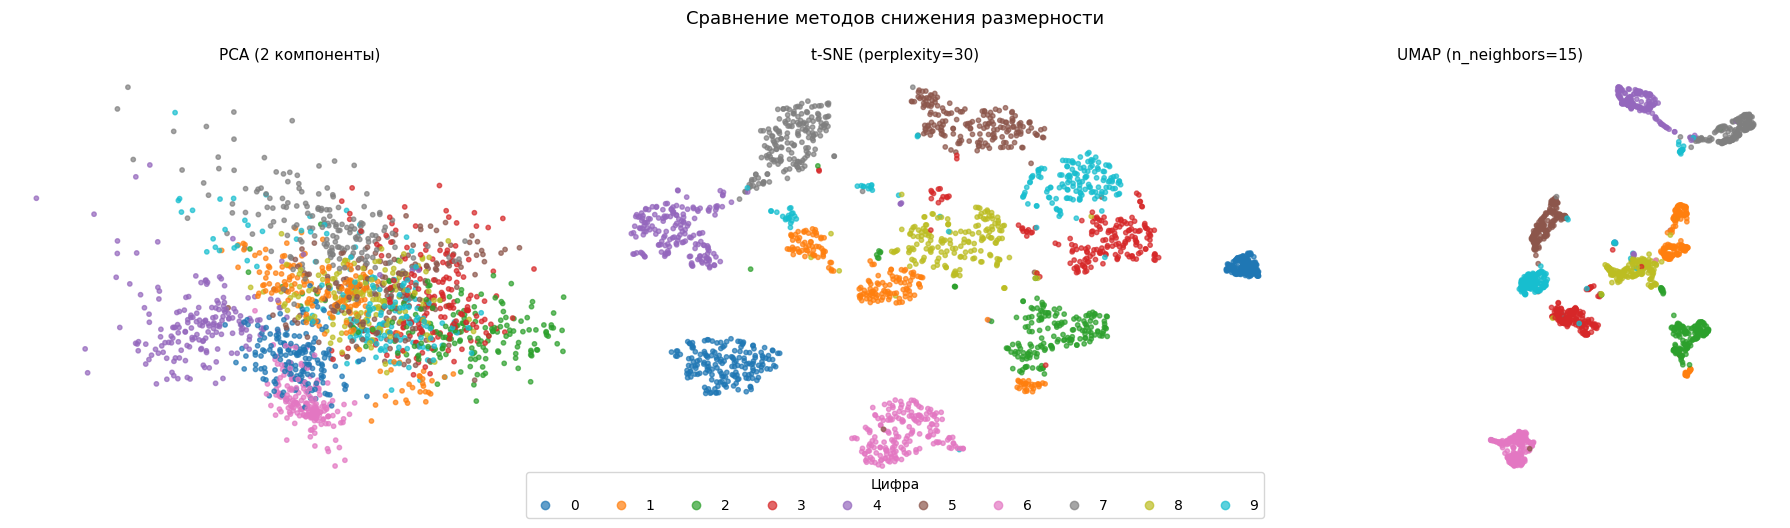

In [16]:
n_plots = 3 if UMAP_AVAILABLE else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))

projections = [
    (X_pca2, 'PCA (2 компоненты)'),
    (X_tsne, 't-SNE (perplexity=30)'),
]
if UMAP_AVAILABLE:
    projections.append((X_umap, 'UMAP (n_neighbors=15)'))

for ax, (X_proj, title) in zip(axes, projections):
    scatter = ax.scatter(X_proj[:, 0], X_proj[:, 1],
                         c=y, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

handles, _ = scatter.legend_elements()
fig.legend(handles, [str(i) for i in range(10)],
           loc='lower center', ncol=10, title='Цифра',
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Сравнение методов снижения размерности', fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 9. Количественная оценка: Silhouette Score

In [17]:
from sklearn.metrics import silhouette_score

scores = {}
scores['PCA (2 компоненты)'] = silhouette_score(X_pca2, y)
scores['t-SNE'] = silhouette_score(X_tsne,y)
if UMAP_AVAILABLE:
    scores['UMAP'] = silhouette_score(X_umap,y)
    
print("Silhouette Score (выше = лучше):")
print("-" * 35)
for name, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f"{name:25s}: {score:.4f}")

Silhouette Score (выше = лучше):
-----------------------------------
UMAP                     : 0.5887
t-SNE                    : 0.4854
PCA (2 компоненты)       : 0.0547


---
## Шаг 10. Реконструкция из PCA

PCA позволяет восстановить исходные данные через `inverse_transform`. Посмотрим, как выглядит реконструкция при разном числе компонент.

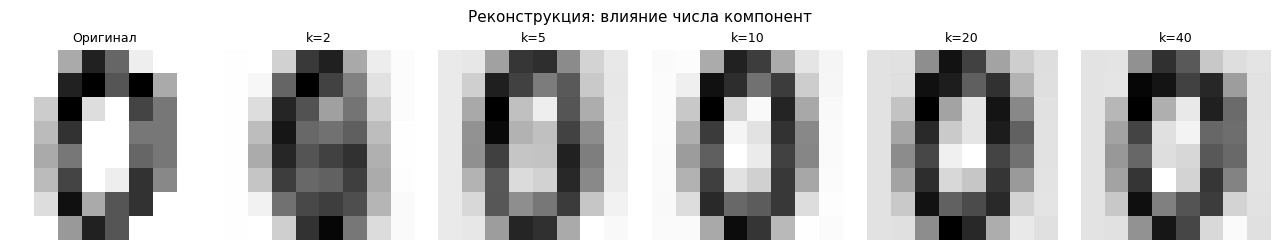

In [18]:
sample_idx = 0
x_original = X_scaled[sample_idx:sample_idx+1]

fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))

# Оригинал
axes[0].imshow(scaler.inverse_transform(x_original).reshape(8, 8), cmap='gray_r')
axes[0].set_title('Оригинал', fontsize=9)
axes[0].axis('off')

for ax, k in zip(axes[1:], [2, 5, 10, 20, 40]):
    pca_k = PCA(n_components=k, random_state=42)
    pca_k.fit(X_scaled)
    x_proj = pca_k.transform(x_original)
    x_rec = pca_k.inverse_transform(x_proj)
    x_rec_original_scale = scaler.inverse_transform(x_rec)
    
    ax.imshow(x_rec_original_scale.reshape(8,8),cmap='gray_r')
    ax.set_title(f'k={k}', fontsize=9)
    ax.axis('off')

plt.suptitle('Реконструкция: влияние числа компонент', fontsize=11)
plt.tight_layout()
plt.show()

По изображениям видно, что при малом кол-ве компонент изображение довольно смазаное, так как сами компоненты сохранили в себе не всю информацию, на 40 компоненте видно, что очертания идентичные (была сохранена основная информация), а края смазаны, что не удивительно ведь они не несут никакой прикладной информации

---
## Выводы

### Ваши выводы

**1. Число компонент PCA:**
- Для сохранения 80% дисперсии нужно 21 компонента из 64.
- Для сохранения 95% дисперсии нужно 40 компонент из 64.

**2. PCA как препроцессинг:**
- Accuracy без PCA: 0.9722
- Accuracy с PCA (95%): 0.9639
- Accuracy с PCA (80%): 0.9472
- Вывод: PCA помогает эффективно снижать размерность нивелируя шум, так как находит собственные значения через матрицу ковариации, то мы как раз и убираем этот шум в виде скорелированных признаков

**3. Сравнение проекций:**
- Лучший Silhouette Score: 0.5887 (метод: UMAP)
- Цифры, которые сложнее всего разделить: 8 и 3, 9 и 3

**4. Вывод о методах:**
- PCA лучше всего применять на скореллированных признаках в датасете, он довольно эффективно помогает чистить данные от лишних признаков и явного шума при заданном трейд-оффе, UMAP и t-SNE лучше всего юзать для визуализации, для препроцессинга как PCA t-SNE не используется, с UMAP так можно, но в данной работе он использовался для визуализации